<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Pro/AI_HW1_Regression_with_inference_pro_pt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (pro). Часть 1**

В этом домашнем задании (его первой части) вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;


> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$



**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import phik

from ydata_profiling import ProfileReport

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
random.seed(42)
np.random.seed(42)

### **Задание 0**
Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

`Для воспроизводимости результатов`

# **Часть 1 | EDA**


Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (1.7 балла)
- Визуализации признаков и их анализ (1.6 балл)

Всего можно набрать 3.3 основных балла и 0.25 бонусных.

В следующих частях, вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (1.7 балла)**

In [2]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(0.4 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)(0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла).

In [3]:
train_missed_values = df_train.isna().sum()
train_missed_values[train_missed_values > 0]

mileage      202
engine       202
max_power    196
torque       203
seats        202
dtype: int64

In [4]:
test_missed_values = df_test.isna().sum()
test_missed_values[test_missed_values > 0]

mileage      19
engine       19
max_power    19
torque       19
seats        19
dtype: int64

In [5]:
df_train.duplicated().sum()

985

In [6]:
df_test.duplicated().sum()

62

In [7]:
df_train[df_train.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
254,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
258,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
325,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
326,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6880,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37 kmpl,1461 CC,108.45 bhp,240Nm@ 1750rpm,5.0
6881,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09 kmpl,1248 CC,88.50 bhp,200Nm@ 1750rpm,5.0
6989,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
6997,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [8]:
df_test[df_test.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
200,Maruti Swift AMT VVT VXI,2019,650000,5621,Petrol,Trustmark Dealer,Automatic,First Owner,22.0 kmpl,1197 CC,81.80 bhp,113Nm@ 4200rpm,5.0
235,Hyundai Grand i10 1.2 CRDi Sportz,2017,450000,56290,Diesel,Dealer,Manual,First Owner,24.0 kmpl,1186 CC,73.97 bhp,190.24nm@ 1750-2250rpm,5.0
238,Toyota Camry 2.5 Hybrid,2016,2000000,68089,Petrol,Trustmark Dealer,Automatic,First Owner,19.16 kmpl,2494 CC,157.7 bhp,213Nm@ 4500rpm,5.0
253,Tata Safari Storme EX,2015,503000,110000,Diesel,Individual,Manual,First Owner,14.1 kmpl,2179 CC,147.94 bhp,320Nm@ 1500-3000rpm,7.0
269,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,Mercedes-Benz S-Class S 350 CDI,2017,6000000,37000,Diesel,Dealer,Automatic,First Owner,13.5 kmpl,2987 CC,254.79 bhp,620Nm@ 1600-2400rpm,5.0
936,BMW X4 M Sport X xDrive20d,2019,5500000,8500,Diesel,Dealer,Automatic,First Owner,16.78 kmpl,1995 CC,190 bhp,400Nm@ 1750-2500rpm,5.0
949,Toyota Camry 2.5 Hybrid,2016,2000000,68089,Petrol,Trustmark Dealer,Automatic,First Owner,19.16 kmpl,2494 CC,157.7 bhp,213Nm@ 4500rpm,5.0
971,Maruti Ertiga SHVS ZDI Plus,2017,750000,50000,Diesel,Individual,Manual,First Owner,24.52 kmpl,1248 CC,88.5 bhp,200Nm@ 1750rpm,7.0


In [9]:
ProfileReport(df_train, title = 'Pandas Profiling Report')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 45.45it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**В данных есть пропуски и дубликаты. Распределения выглядят нормально. Есть странности в типах данных.**

### **Задание 2 (0.2 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?
- [ ] Сделайте выводы по статистикам. Отсутсвие выводов равносильно по баллам невыполнению задания.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [10]:
df_train.describe()

,year,selling_price,km_driven,seats
count,6999.000000,6.999000e+03,6.999000e+03,6797.000000
mean,2013.818403,6.395152e+05,6.958462e+04,5.419008
std,4.053095,8.089419e+05,5.772400e+04,0.965767
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [11]:
df_test.describe()

,year,selling_price,km_driven,seats
count,1000.000000,1.000000e+03,1000.000000,981.000000
mean,2013.681000,6.179010e+05,71393.341000,5.410805
std,4.012149,7.585539e+05,48486.218662,0.919985
min,1995.000000,3.100000e+04,1303.000000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,9.000000


In [12]:
df_train.describe(include = object)

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6999,6999,6999,6999,6999,6797,6797,6803,6796
unique,1924,4,3,2,5,386,120,316,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,116,3793,5826,6095,4587,197,885,330,468


In [13]:
df_test.describe(include = object)

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


In [14]:
num_columns = df_train.select_dtypes(include = [int, float]).columns
num_columns

Index(['year', 'selling_price', 'km_driven', 'seats'], dtype='object')

In [15]:
df_train[num_columns].agg(['mean', 'median'])

,year,selling_price,km_driven,seats
mean,2013.818403,639515.197171,69584.615517,5.419008
median,2015.000000,450000.000000,60000.000000,5.000000


In [16]:
df_test[num_columns].agg(['mean', 'median'])

,year,selling_price,km_driven,seats
mean,2013.681,617901.042,71393.341,5.410805
median,2014.000,434999.000,61500.000,5.000000


**Видны аномальные значения, возможно, стоит поработать с ними в дальнейшем, например удалить или заменить граничными значениями. Тренировчные данные в обещем и целом похожи на тестовые.**

### **Задание 3 (0.2 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.01 балла)
- [ ] Отобразите такие объекты (0.01 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.01 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.01 балла)
- [ ] Подумайте, могут ли в данных быть другие скрытые дубли? Предложите, как их можно отлавливать. (0.16 балла)

P.S тут данные без подвоха, но выводы нам нужны.

In [17]:
df_train.drop('selling_price', axis = 1).duplicated().sum()

1159

In [18]:
df_train[df_train.drop('selling_price', axis = 1).duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
254,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
258,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
268,Maruti Swift Dzire VXI,2014,400000,70000,Petrol,Individual,Manual,Second Owner,19.1 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
325,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6947,Chevrolet Spark 1.0 LS,2010,140000,60000,Petrol,Individual,Manual,Second Owner,18.0 kmpl,995 CC,62 bhp,90.3Nm@ 4200rpm,5.0
6984,Ford Freestyle Titanium Plus Diesel BSIV,2018,746000,24000,Diesel,Individual,Manual,First Owner,24.4 kmpl,1498 CC,98.63 bhp,215Nm@ 1750-3000rpm,5.0
6989,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
6997,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [19]:
df_train.drop_duplicates(subset = df_train.drop('selling_price', axis = 1).columns, keep = 'first', inplace = True)

In [20]:
df_train.reset_index(drop = True, inplace = True)

In [21]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.3 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [22]:
# Имеется значение в max_power без числа, заменим его None, чтобы был как пропуск для дальнейшего заполнения
df_train.loc[df_train['max_power'] == ' bhp', 'max_power'] = np.nan

In [23]:
change_type_cols = ['mileage', 'engine', 'max_power']

for col in change_type_cols:
    df_train[col] = df_train[col].str.split().str[0].astype('float')
    df_test[col] = df_test[col].str.split().str[0].astype('float')

In [24]:
df_train['torque_value'] = df_train['torque'].str.split('@').str[0].str.lower().str.split('nm').str[0].str.split('kgm').str[0].str.split('/').str[0].str.strip().astype('float')
df_train.loc[df_train['torque'].str.contains('kgm', na = False), 'torque_value'] *= 9.80665
df_train['torque_value']

0       190.000000
1       250.000000
2       219.668960
3       112.776475
4       113.750000
           ...    
5835     96.100000
5836     90.000000
5837    113.700000
5838    235.359600
5839    190.000000
Name: torque_value, Length: 5840, dtype: float64

In [25]:
df_train['max_torque_rpm'] = df_train['torque'].str.lower().str.replace('@', '').str.replace('nm', '').str.replace(',', '').str.replace('/', '').str.split('rpm').str[0].str.replace('(kgm ', '').str.split().str[-1].str.split('-').str[-1].str.split('~').str[-1].str.replace('(', '').astype('float')
df_train['max_torque_rpm']

0       2000.0
1       2500.0
2       2750.0
3       4500.0
4       4000.0
         ...  
5835    3000.0
5836    3500.0
5837    4000.0
5838    2750.0
5839    2000.0
Name: max_torque_rpm, Length: 5840, dtype: float64

In [26]:
df_test['torque_value'] = df_test['torque'].str.split('@').str[0].str.lower().str.split('nm').str[0].str.split('kgm').str[0].str.split('/').str[0].str.strip().str.split('(').str[0].astype('float')
df_test.loc[df_test['torque'].str.contains('kgm', na = False), 'torque_value'] *= 9.80665
df_test['torque_value']

0      260.00000
1      260.00000
2      172.00000
3      200.00000
4       96.00000
         ...    
995     99.04000
996    114.70000
997    219.66896
998    111.80000
999    200.00000
Name: torque_value, Length: 1000, dtype: float64

In [27]:
df_test['max_torque_rpm'] = df_test['torque'].str.lower().str.replace('@', '').str.replace('nm', '').str.replace(',', '').str.replace('/', '').str.split('rpm').str[0].str.replace('(kgm ', '').str.split().str[-1].str.split('-').str[-1].str.split('~').str[-1].str.replace('(', '').astype('float')
df_test['max_torque_rpm']

0      2200.0
1      2750.0
2      4300.0
3      1750.0
4      3000.0
        ...  
995    4500.0
996    4000.0
997    2750.0
998    4000.0
999    1750.0
Name: max_torque_rpm, Length: 1000, dtype: float64

In [28]:
df_train = df_train.drop('torque', axis = 1).rename(columns = {'torque_value': 'torque'})
df_test = df_test.drop('torque', axis = 1).rename(columns = {'torque_value': 'torque'})

### **Задание 5 (0.3 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [29]:
medians = df_train.select_dtypes(include = [int, float]).median()

df_train.fillna(medians, inplace = True)
df_test.fillna(medians, inplace = True)

In [30]:
df_train.isna().sum()

name              0
year              0
selling_price     0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage           0
engine            0
max_power         0
seats             0
torque            0
max_torque_rpm    0
dtype: int64

In [31]:
df_test.isna().sum()

name              0
year              0
selling_price     0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage           0
engine            0
max_power         0
seats             0
torque            0
max_torque_rpm    0
dtype: int64

**Медиана устойчива к выбросам, поэтому это хорошее решение и лучше среднего. По тренировочным данным для train и test.**

### **Задание 6 (0.2 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [32]:
df_train[['engine', 'seats']] = df_train[['engine', 'seats']].astype('int')
df_train[['engine', 'seats']]

,engine,seats
0,1248,5
1,1498,5
2,1396,5
3,1298,5
4,1197,5
...,...,...
5835,1086,5
5836,998,5
5837,1197,5
5838,1493,5


In [33]:
df_test[['engine', 'seats']] = df_test[['engine', 'seats']].astype('int')
df_test[['engine', 'seats']]

,engine,seats
0,2498,7
1,1497,5
2,1799,5
3,1498,5
4,1172,5
...,...,...
995,1086,5
996,1197,5
997,1396,5
998,1197,5


**seats содержит ограниченное количество значений и его вполне можно закодировать.**

### **Задание 7 (0.1 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [34]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,5.426712,175.559815,3038.631507
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,0.982344,116.922685,918.277038
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000,14.900000,400.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,5.000000,111.795810,2250.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,5.000000,160.000000,3000.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,5.000000,200.013915,4000.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000,3726.527000,21800.000000


In [35]:
df_test.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque,max_torque_rpm
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.33881,1454.87600,90.841670,5.403000,177.406018,3078.456000
std,4.012149,7.585539e+05,48486.218662,3.95175,521.99574,34.893389,0.912921,103.832025,903.502756
min,1995.000000,3.100000e+04,1303.000000,0.00000,624.00000,34.200000,4.000000,24.000000,400.000000
25%,2011.000000,2.500000e+05,37000.000000,16.55000,1197.00000,69.000000,5.000000,111.700000,2500.000000
50%,2014.000000,4.349990e+05,61500.000000,19.37000,1248.00000,82.425000,5.000000,160.000000,3000.000000
75%,2017.000000,6.700000e+05,100000.000000,22.30000,1582.00000,102.000000,5.000000,205.000000,4000.000000
max,2020.000000,6.000000e+06,375000.000000,32.26000,3604.00000,280.000000,9.000000,1421.964250,5200.000000


**Смещения в распределении не видно, но в теории это возможно, если пропуски сильно зависят от других переменных.**

## **Визуализации и корреляция (1.6 балла + 0.25)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

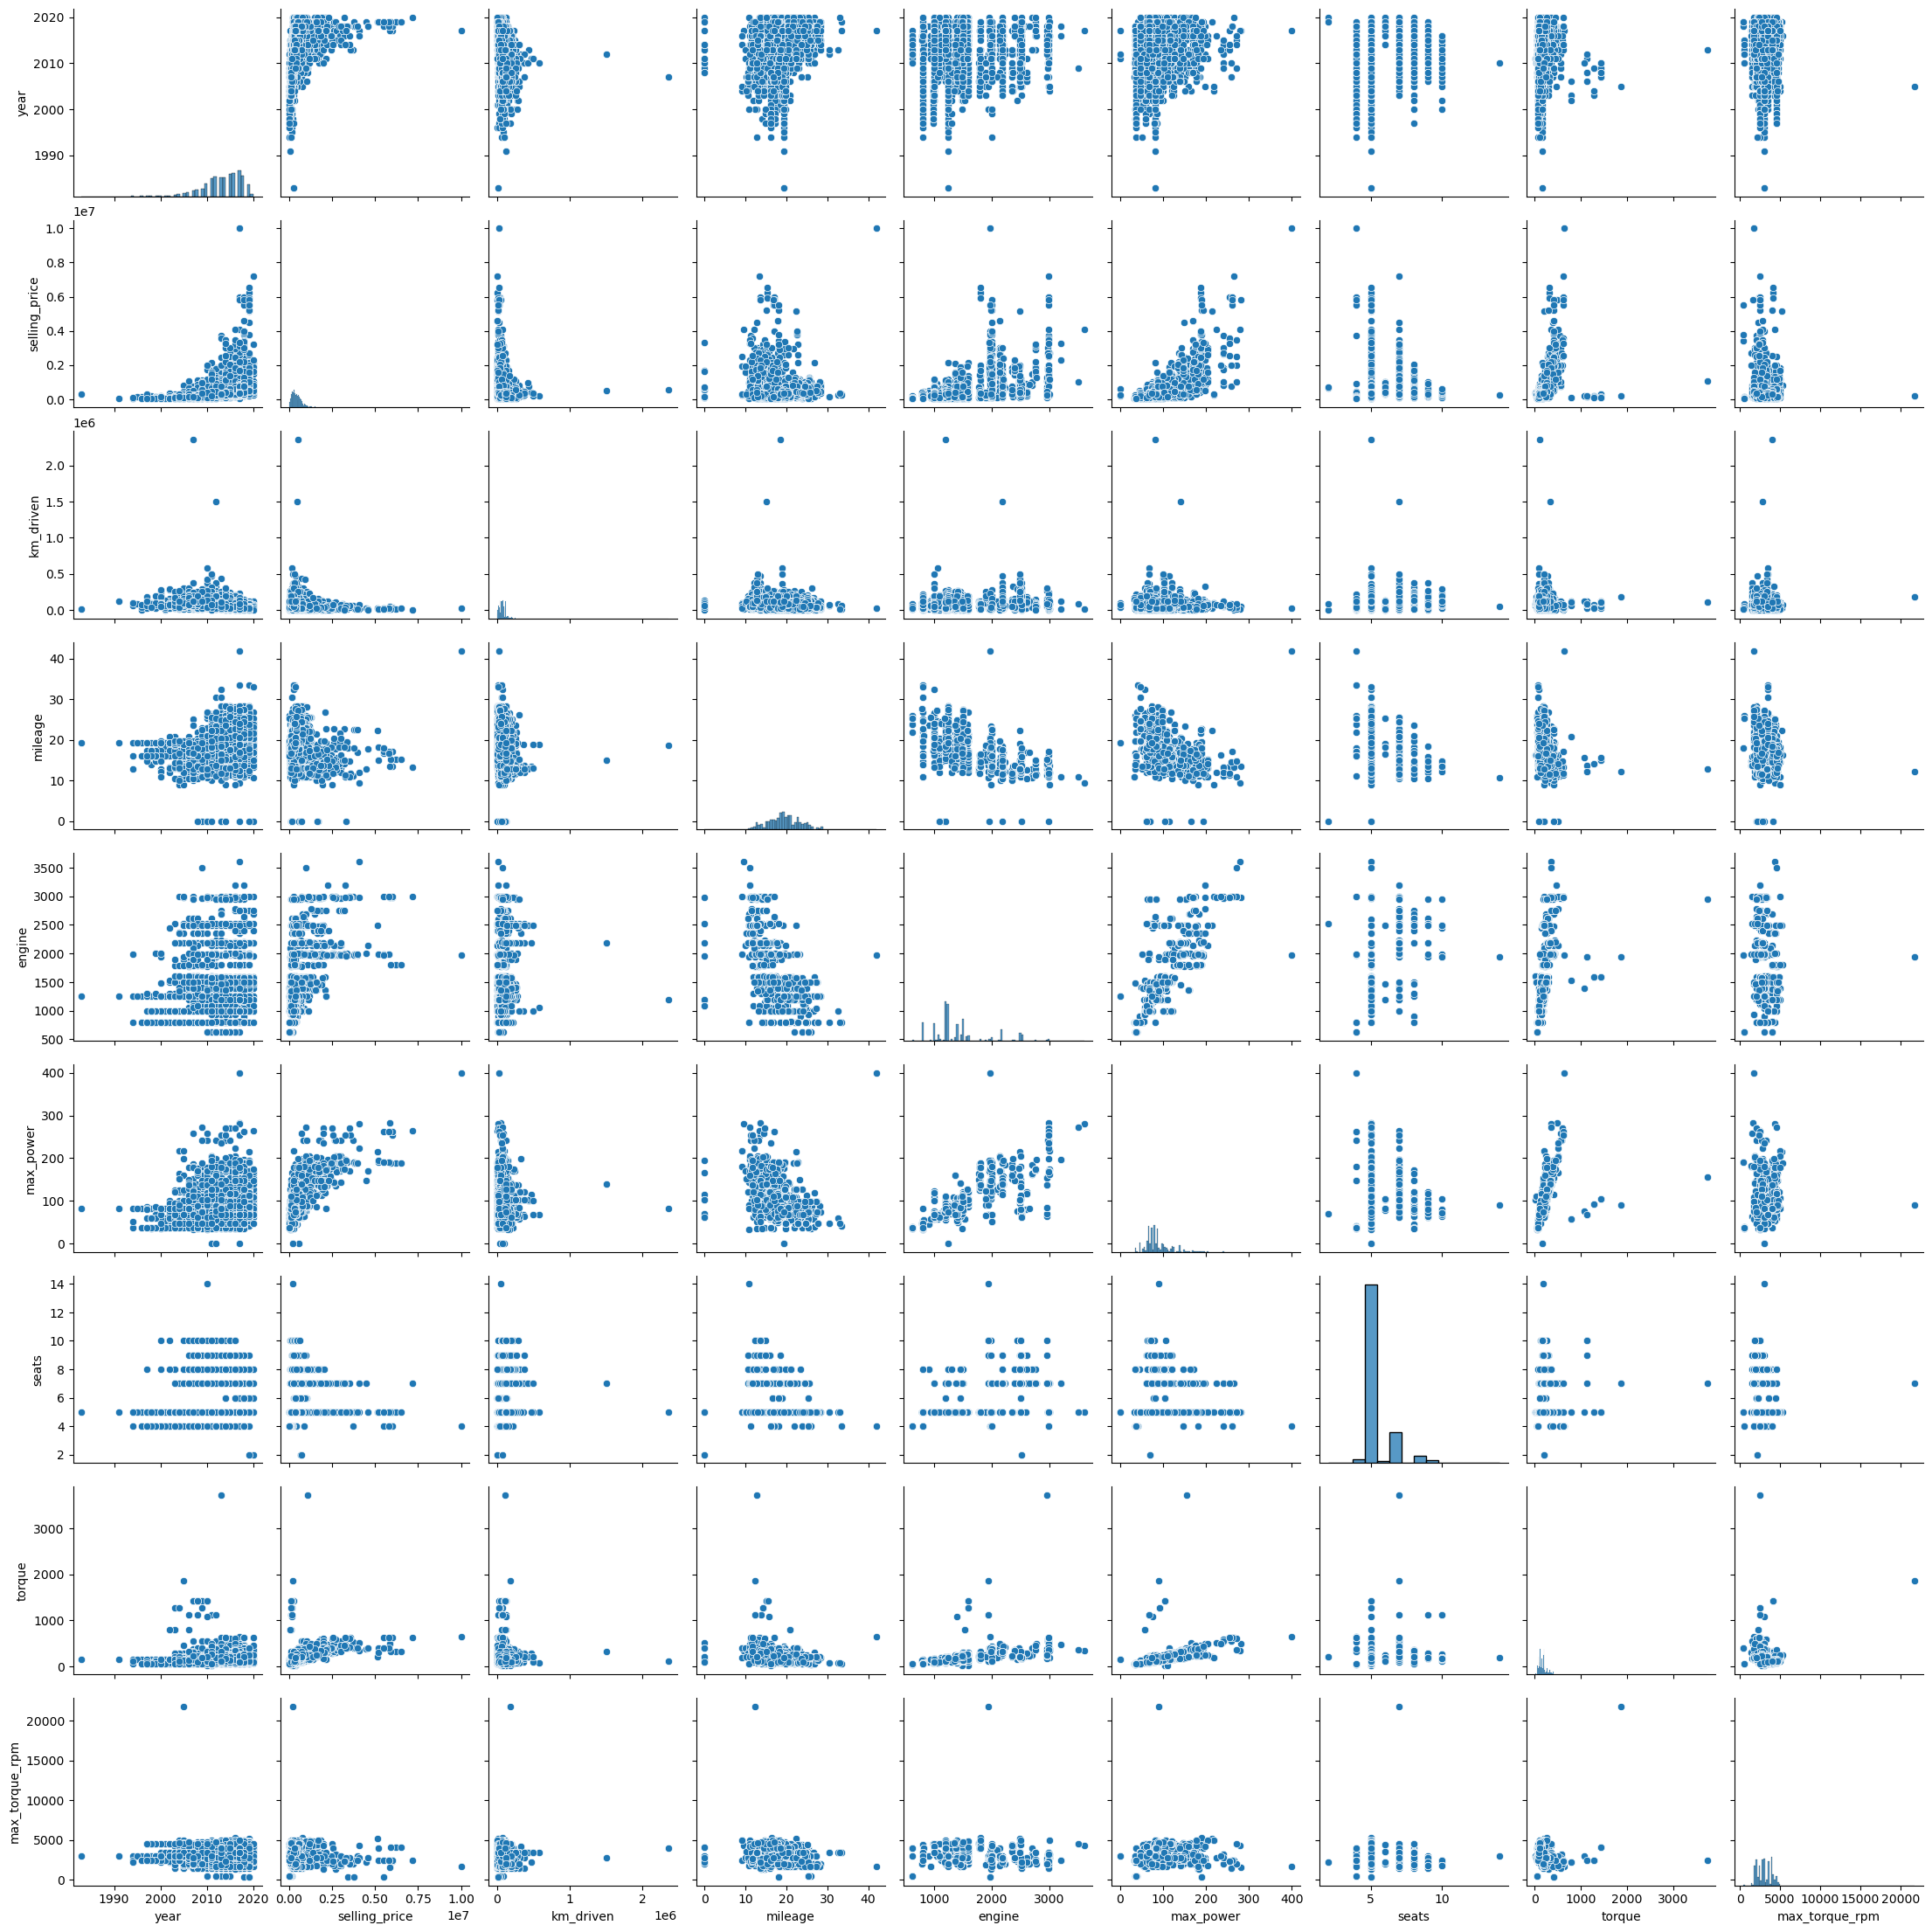

In [36]:
sns.pairplot(df_train.select_dtypes(include = [int, float]))
plt.show()

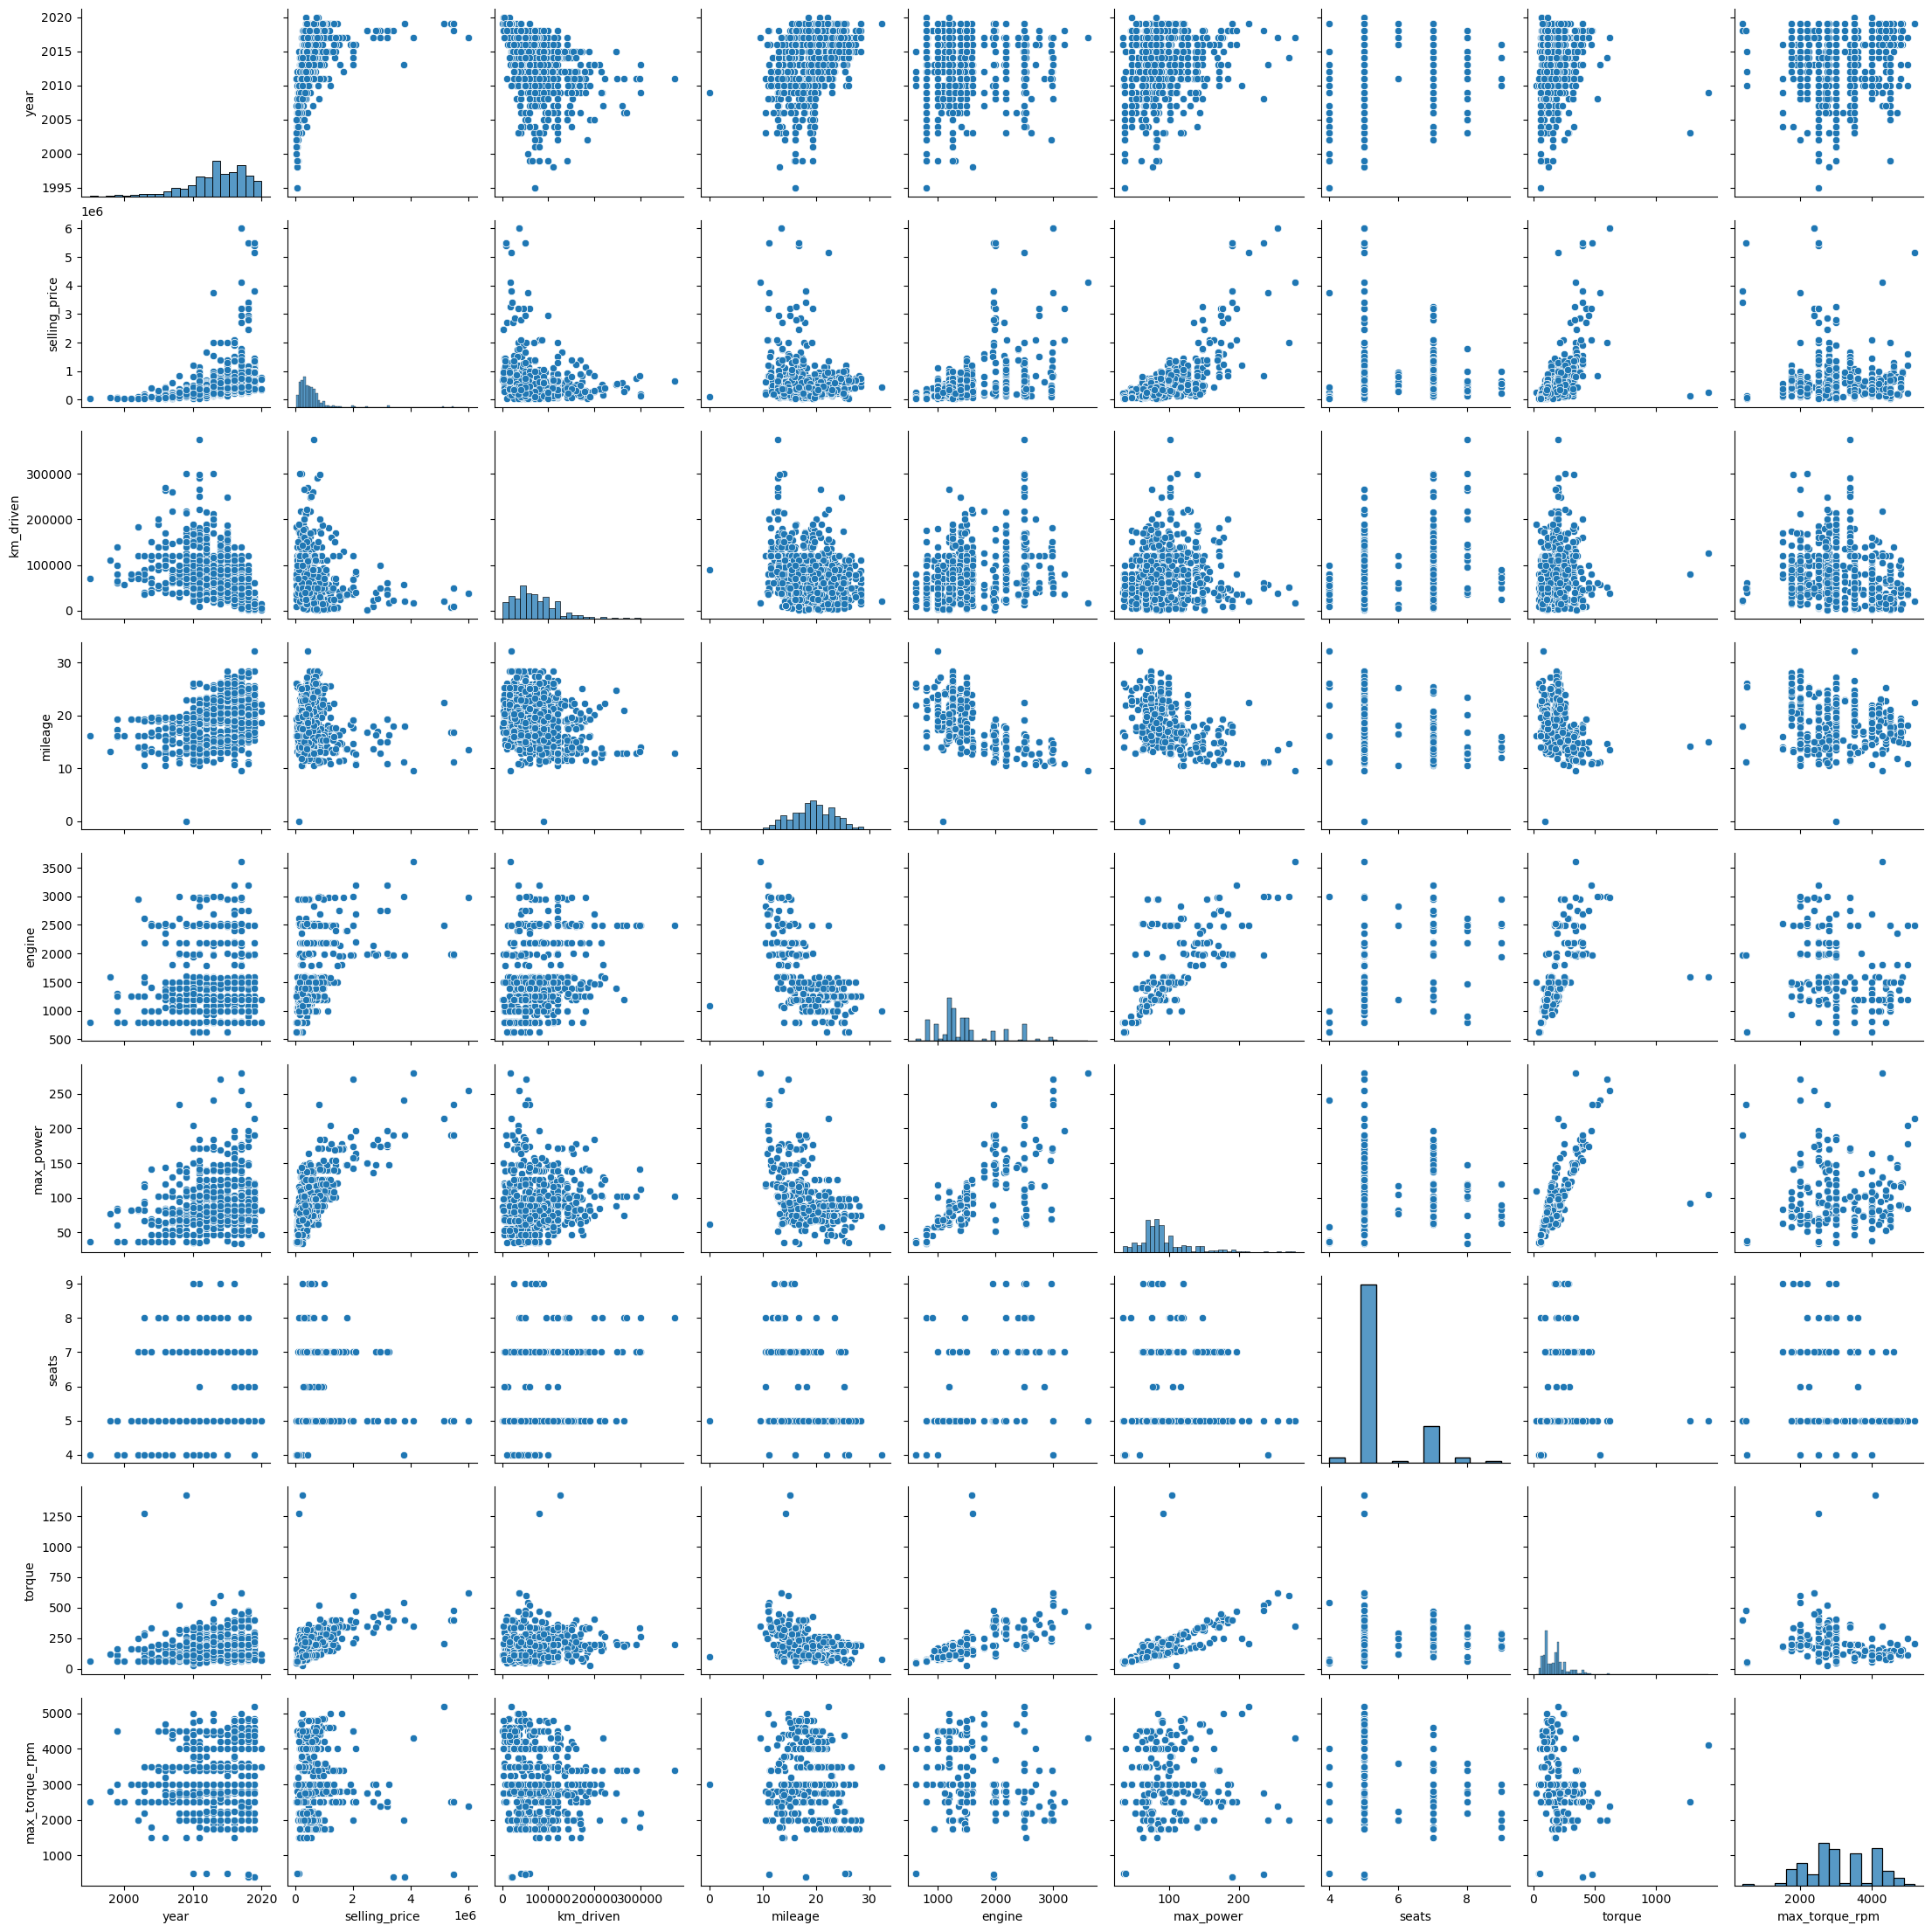

In [37]:
sns.pairplot(df_test.select_dtypes(include = [int, float]))
plt.show()

**Часто на основании распределений улавливается нелинейная связь с целевой переменной и возможна корреляция признаков. В принципе графики похожи на train и test.**

### **Задание 9 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

In [38]:
df_corr = df_train.select_dtypes(include = [int, float]).corr()
df_corr

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque,max_torque_rpm
year,1.000000,0.427279,-0.368966,0.341334,0.002819,0.156858,0.041178,0.050527,0.047780
selling_price,0.427279,1.000000,-0.164828,-0.104769,0.447672,0.692814,0.149953,0.433930,-0.092190
km_driven,-0.368966,-0.164828,1.000000,-0.182086,0.229766,0.024588,0.192328,0.105192,-0.197747
mileage,0.341334,-0.104769,-0.182086,1.000000,-0.572893,-0.373390,-0.451059,-0.223330,-0.188688
engine,0.002819,0.447672,0.229766,-0.572893,1.000000,0.681117,0.652172,0.564768,-0.234098
max_power,0.156858,0.692814,0.024588,-0.373390,0.681117,1.000000,0.244112,0.613196,-0.014401
seats,0.041178,0.149953,0.192328,-0.451059,0.652172,0.244112,1.000000,0.299054,-0.194794
torque,0.050527,0.433930,0.105192,-0.223330,0.564768,0.613196,0.299054,1.000000,-0.241753
max_torque_rpm,0.047780,-0.092190,-0.197747,-0.188688,-0.234098,-0.014401,-0.194794,-0.241753,1.000000


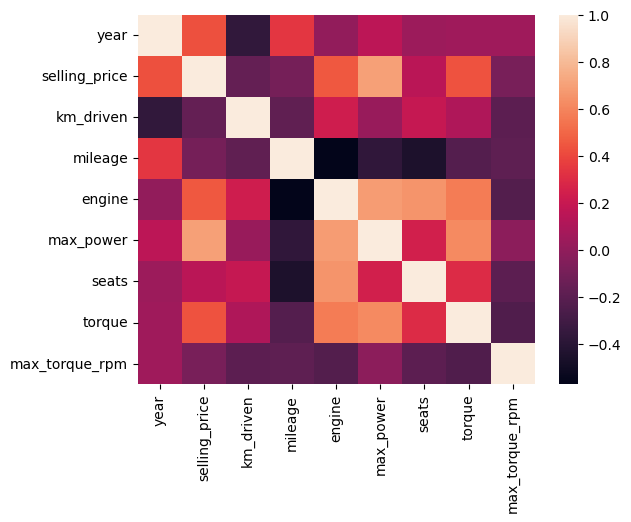

In [39]:
sns.heatmap(df_corr)
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?
 - Изучите типы корреляций в `pd.corr()`. Какую вы использовали по умолчанию?

**engine и year. selling_price и max_power; max_power, seats, torque и engine. Да, так как есть отрицательная корреляция. По умолчанию используется корреляция Пирсона.**

### **Задание 10 (0.6 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче, попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ] Сделайте выводы


Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


In [40]:
def corr_spearman(df_num):
    df = df_num.values
    
    n_cols = df.shape[1]
    n_rows = df.shape[0]
    ranks = np.zeros_like(df)
    
    for col in range(n_cols):
        sorted_indices = np.argsort(df[:, col])
        sorted_values = df[sorted_indices, col]
        
        i = 0
        current_rank = 1
        
        while i < n_rows:
            j = i
            
            while j < n_rows - 1 and sorted_values[j] == sorted_values[j + 1]:
                j += 1
            
            tie_count = j - i + 1
            avg_rank = current_rank + (tie_count - 1) / 2
            
            for k in range(i, j + 1):
                ranks[sorted_indices[k], col] = avg_rank
            
            current_rank += tie_count
            i = j + 1
    
    corr_matrix = np.corrcoef(ranks.T)
    
    return pd.DataFrame(corr_matrix, index = df_num.columns, columns = df_num.columns)

In [41]:
df_corr_spearman_manual = corr_spearman(df_train.select_dtypes(include = [int, float]))
df_corr_spearman_manual

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque,max_torque_rpm
year,1.000000,0.707123,-0.569659,0.346132,-0.038056,0.165798,0.048291,0.107532,0.076879
selling_price,0.707123,1.000000,-0.295665,0.026186,0.463577,0.612258,0.317605,0.584676,-0.120918
km_driven,-0.569659,-0.295665,1.000000,-0.198466,0.304504,0.040919,0.195317,0.239275,-0.314982
mileage,0.346132,0.026186,-0.198466,1.000000,-0.429871,-0.308824,-0.435458,-0.156872,-0.183376
engine,-0.038056,0.463577,0.304504,-0.429871,1.000000,0.713113,0.527716,0.837535,-0.364814
max_power,0.165798,0.612258,0.040919,-0.308824,0.713113,1.000000,0.304857,0.772466,-0.018566
seats,0.048291,0.317605,0.195317,-0.435458,0.527716,0.304857,1.000000,0.439430,-0.189764
torque,0.107532,0.584676,0.239275,-0.156872,0.837535,0.772466,0.439430,1.000000,-0.516196
max_torque_rpm,0.076879,-0.120918,-0.314982,-0.183376,-0.364814,-0.018566,-0.189764,-0.516196,1.000000


In [42]:
df_corr_spearman_library = df_train.select_dtypes(include = [int, float]).corr(method = 'spearman')
df_corr_spearman_library

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque,max_torque_rpm
year,1.000000,0.707123,-0.569659,0.346132,-0.038056,0.165798,0.048291,0.107532,0.076879
selling_price,0.707123,1.000000,-0.295665,0.026186,0.463577,0.612258,0.317605,0.584676,-0.120918
km_driven,-0.569659,-0.295665,1.000000,-0.198466,0.304504,0.040919,0.195317,0.239275,-0.314982
mileage,0.346132,0.026186,-0.198466,1.000000,-0.429871,-0.308824,-0.435458,-0.156872,-0.183376
engine,-0.038056,0.463577,0.304504,-0.429871,1.000000,0.713113,0.527716,0.837535,-0.364814
max_power,0.165798,0.612258,0.040919,-0.308824,0.713113,1.000000,0.304857,0.772466,-0.018566
seats,0.048291,0.317605,0.195317,-0.435458,0.527716,0.304857,1.000000,0.439430,-0.189764
torque,0.107532,0.584676,0.239275,-0.156872,0.837535,0.772466,0.439430,1.000000,-0.516196
max_torque_rpm,0.076879,-0.120918,-0.314982,-0.183376,-0.364814,-0.018566,-0.189764,-0.516196,1.000000


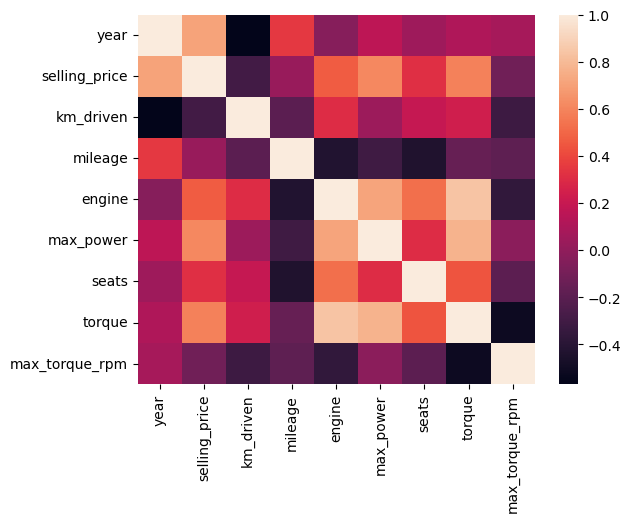

In [43]:
sns.heatmap(df_corr_spearman_library)
plt.show()

In [44]:
df_corr_phik = df_train.phik_matrix()
df_corr_phik

interval columns not set, guessing: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque', 'max_torque_rpm']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque,max_torque_rpm
name,1.000000,0.948995,0.994871,0.000000,1.000000,0.799127,1.000000,0.830098,0.999690,1.000000,0.997906,0.999985,1.000000,0.999954
year,0.948995,1.000000,0.219841,0.081574,0.205834,0.232412,0.153714,0.418636,0.279253,0.213156,0.381639,0.288178,0.106517,0.107833
selling_price,0.994871,0.219841,1.000000,0.000000,0.157885,0.334505,0.463058,0.557641,0.649768,0.503682,0.872166,0.196447,0.516988,0.070343
km_driven,0.000000,0.081574,0.000000,1.000000,0.046285,0.000000,0.012824,0.087887,0.081625,0.210747,0.000000,0.096223,0.000000,0.000000
fuel,1.000000,0.205834,0.157885,0.046285,1.000000,0.050771,0.053721,0.030943,0.582304,0.644421,0.236006,0.450714,0.119750,0.689584
seller_type,0.799127,0.232412,0.334505,0.000000,0.050771,1.000000,0.127968,0.176612,0.064736,0.160346,0.331904,0.032173,0.250694,0.037127
transmission,1.000000,0.153714,0.463058,0.012824,0.053721,0.127968,1.000000,0.096990,0.331889,0.520161,0.511877,0.045734,0.535045,0.110123
owner,0.830098,0.418636,0.557641,0.087887,0.030943,0.176612,0.096990,1.000000,0.152406,0.186011,0.121438,0.046741,0.054723,0.018983
mileage,0.999690,0.279253,0.649768,0.081625,0.582304,0.064736,0.331889,0.152406,1.000000,0.588155,0.687235,0.679979,0.189285,0.393082
engine,1.000000,0.213156,0.503682,0.210747,0.644421,0.160346,0.520161,0.186011,0.588155,1.000000,0.720780,0.603400,0.423769,0.466539


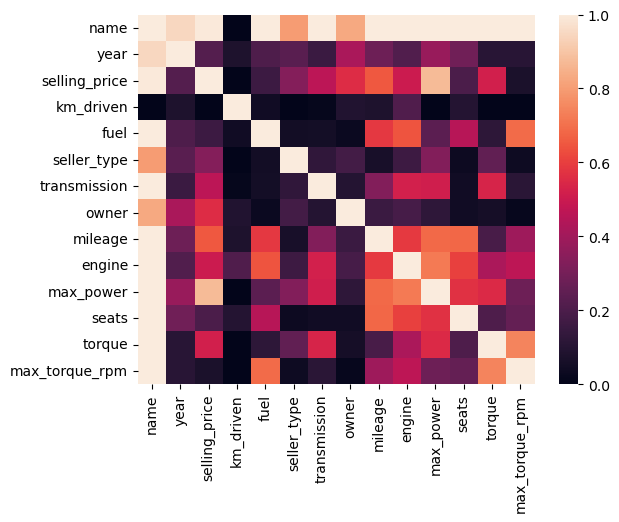

In [45]:
sns.heatmap(df_corr_phik)
plt.show()

**Ручная реализация совпаадет с библиотечной, видно, что зависимости изменились, то есть в данных есть нелинейные зависимости, которые можно попробовать уловить в дальнейшем при создании новых признаков.**

### **Дополнительные визуализации (бонус 0.25 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.
Один график: 0.125 балла, при условии, что он обоснован.

In [46]:
# your code here

# **Часть 2 (1.7 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.05 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [47]:
y_train = df_train['selling_price']
X_train = df_train.select_dtypes(include = [int, float]).drop('selling_price', axis = 1)

In [48]:
assert X_train.shape == (5840, 6)

AssertionError: 

In [49]:
y_test = df_test['selling_price']
X_test = df_test.select_dtypes(include = [int, float]).drop('selling_price', axis = 1)

In [50]:
assert X_test.shape == (1000, 6)

AssertionError: 

### **Задание 12. (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [52]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.602658013921268
R2 на test: 0.6057127598465435
MSE на train: 113893446649.4302
MSE на test: 226647564764.0798


**Значения R2 на тренировочных данных почти такие же как на тестовых, но MSE всё же становится хуже на тренировочных. Возможно, стоит пытаться оптимизировать именно R2.**

### **Задание 13 (0.15 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [53]:
def R2(y, y_pred):
    return 1 - sum((y_pred - y) ** 2) / sum((y - y.mean()) ** 2)

In [54]:
print(f'R2 на train: {R2(y_train, y_pred_train)}')
print(f'R2 на test: {R2(y_test, y_pred_test)}')

R2 на train: 0.602658013921268
R2 на test: 0.6057127598465435


**y_pred - предсказание модели, y - истинные значения, (y с крышкой в формуле) y.mean() - среднее значение.**

### **Бонус (0.15 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [55]:
def R2_adjusted(y, y_pred, p):    
    return 1 - (1 - R2(y, y_pred)) * (len(y) - 1) / (len(y) - p - 1)

In [56]:
print(f'R2_adjusted на train: {R2_adjusted(y_train, y_pred_train, X_train.shape[1])}')
print(f'R2_adjusted на test: {R2_adjusted(y_test, y_pred_test, X_train.shape[1])}')

R2_adjusted на train: 0.6021128697112474
R2_adjusted на test: 0.6025298154255266


**Adjusted R2 используется при сравнении моделей с разным количеством признаков. Может быть применён для отбора признаков, сравнение разных типов моделей, валидации добавления новых признаков.**

### **Задание 14 (0.05 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [59]:
y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.6026580139212672
R2 на test: 0.6057127598465389
MSE на train: 113893446649.43048
MSE на test: 226647564764.08246


### **Задание 15 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [60]:
features = X_train.columns
coefs = lr.coef_

feature_importance = pd.DataFrame({'feature': features, 'coef': np.abs(coefs)})
feature_importance = feature_importance.sort_values('coef', ascending = False)
feature_importance

,feature,coef
4,max_power,331152.728980
0,year,166547.982722
7,max_torque_rpm,64228.636117
1,km_driven,49053.644034
5,seats,30307.458976
3,engine,19917.159119
2,mileage,11315.273999
6,torque,5764.037023


**max_power	оказался наиболее информативным.**

### **Задание 16 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [61]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train_scaled, y_train)

Lasso()

In [62]:
y_pred_train = lasso.predict(X_train_scaled)
y_pred_test = lasso.predict(X_test_scaled)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.6026580138772599
R2 на test: 0.6057113836774877
MSE на train: 113893446662.04465
MSE на test: 226648355825.3505


In [63]:
features = X_train.columns
coefs = lasso.coef_

feature_importance = pd.DataFrame({'feature': features, 'coef': np.abs(coefs)})
feature_importance = feature_importance.sort_values('coef', ascending = False)
feature_importance

,feature,coef
4,max_power,331153.988947
0,year,166545.937253
7,max_torque_rpm,64226.608461
1,km_driven,49052.709126
5,seats,30303.655463
3,engine,19915.290672
2,mileage,11312.158367
6,torque,5763.356657


**Нет, не занулила, потому что значения весов очень большие и она их просто уменьшила, для зануления таких весов нужен очень большой коэффициент регуляризации.**

### **Задание 17. Финальный рывок (0.4 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    'max_iter': [1000, 5000, 10000]
}

lasso = Lasso()

grid_search = GridSearchCV(
    estimator = lasso,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 10
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
                         'max_iter': [1000, 5000, 10000]},
             scoring='r2')

In [65]:
best_params = grid_search.best_params_
best_params

{'alpha': 10000, 'max_iter': 1000}

In [66]:
lasso = Lasso(alpha = 10000, max_iter = 1000)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=10000)

In [67]:
y_pred_train = lasso.predict(X_train_scaled)
y_pred_test = lasso.predict(X_test_scaled)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.5998562213631613
R2 на test: 0.5912507940048823
MSE на train: 114696547812.70941
MSE на test: 234960715700.53442


In [68]:
features = X_train.columns
coefs = lasso.coef_

feature_importance = pd.DataFrame({'feature': features, 'coef': np.abs(coefs)})
feature_importance = feature_importance.sort_values('coef', ascending = False)
feature_importance

,feature,coef
4,max_power,337124.855632
0,year,153651.384616
7,max_torque_rpm,49735.452586
1,km_driven,39605.691410
5,seats,441.266895
6,torque,107.147254
2,mileage,0.000000
3,engine,0.000000


**Всего моделей было обучено 8 * 3 * 10 = 240. Перебираемые параметры: alpha - коэффициент регуляризации, max_iter - максимальное количество итераций. Лучший коэффициент регуляризации alpha = 10000, из-за такого большого значения занулились 2 признака: mileage и engine.**

**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [69]:
from sklearn.linear_model import ElasticNet

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [1000, 5000]
}

en = ElasticNet()

grid_search = GridSearchCV(
    estimator = en,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 10
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=ElasticNet(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
                         'max_iter': [1000, 5000]},
             scoring='r2')

In [70]:
best_params = grid_search.best_params_
best_params

{'alpha': 1, 'l1_ratio': 0.9, 'max_iter': 1000}

In [71]:
en = ElasticNet(alpha = 1, l1_ratio = 0.9, max_iter = 1000)
en.fit(X_train_scaled, y_train)

ElasticNet(alpha=1, l1_ratio=0.9)

In [72]:
y_pred_train = en.predict(X_train_scaled)
y_pred_test = en.predict(X_test_scaled)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.5971297855394974
R2 на test: 0.5815502044694553
MSE на train: 115478048846.84387
MSE на test: 240536891572.02542


**Всего моделей было оубчено 7 * 5 * 2 * 10 = 700. Лучшие гиперпараметры: alpha = 1, l1_ratio = 0.9, max_iter = 1000.**

### **Задание 18 (0.35 балла)**

И так, вы обучили все варианты регуляризаций, доступные в sklearn, но не все, что мы обсудили на занятии! И следующее задание о забытой - $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



# **Часть 3 (0.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.1 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [73]:
X_train_cat = df_train.drop('selling_price', axis = 1)
X_test_cat = df_test.drop('selling_price', axis = 1)

In [74]:
assert X_train_cat.shape == (5840, 11)

AssertionError: 

In [75]:
X_train_cat.describe(include = 'object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


In [76]:
X_test_cat.describe(include = 'object')

,name,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000,1000
unique,621,4,3,2,5
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner
freq,15,534,837,877,623


In [77]:
X_train_cat['name'] = df_train['name'].str.split().str[0]
X_test_cat['name'] = df_test['name'].str.split().str[0]

In [78]:
X_train_cat.describe(include = 'object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,30,4,3,2,5
top,Maruti,Diesel,Individual,Manual,First Owner
freq,1804,3177,5223,5336,3603


In [79]:
X_test_cat.describe(include = 'object')

,name,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000,1000
unique,25,4,3,2,5
top,Maruti,Diesel,Individual,Manual,First Owner
freq,290,534,837,877,623


**Было принято решение оставить только первое слово из name (марку). Это существенно снизило количество уникальных значений в столбце, что позоляет применить к нему OHE.**

### **Задание 20 (0.1 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [80]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'seats']

ohe = OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore')
X_train_ohe = ohe.fit_transform(X_train_cat[cat_cols])
X_test_ohe = ohe.transform(X_test_cat[cat_cols])

In [81]:
feature_names = ohe.get_feature_names_out()

X_train_cat[feature_names] = X_train_ohe
X_test_cat[feature_names] = X_test_ohe

X_train_cat = X_train_cat.drop(cat_cols, axis = 1)
X_test_cat = X_test_cat.drop(cat_cols, axis = 1)

In [82]:
X_train_cat.shape

(5840, 54)

In [83]:
X_test_cat.shape

(1000, 54)

**Получилось 54 признака, работа с name помогла получить приемлемое количество признаков без полной его потери.**

### **Задание 21 (0.2 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

**Надо обучать и применять на тренировочных данных, а на тестовых только применять. Столбец удаляется из-за дамми-ловушки (образуется полная линейная зависимость, если сложить все столбцы). Удалять неважные OHE-признаки можно (осторожно, там, где эти признаки потенциально не важны, например, их мало по сравнению с другими), но нужно сохранять хотя бы один признак из каждой категориальной переменной, чтобы не потерять информацию.**

### **Задание 22 (0.1 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [84]:
from sklearn.linear_model import Ridge

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'max_iter': [1000, 5000]
}

ridge = Ridge()

grid_search = GridSearchCV(
    estimator = ridge,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 10
)

grid_search.fit(X_train_cat, y_train)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'max_iter': [1000, 5000]},
             scoring='r2')

In [85]:
best_params = grid_search.best_params_
best_params

{'alpha': 1, 'max_iter': 1000}

In [86]:
ridge = Ridge(alpha = 1, max_iter = 1000)
ridge.fit(X_train_cat, y_train)

Ridge(alpha=1, max_iter=1000)

In [87]:
y_pred_train = ridge.predict(X_train_cat)
y_pred_test = ridge.predict(X_test_cat)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.7718965145307461
R2 на test: 0.7835562419359346
MSE на train: 65383204048.54925
MSE на test: 124418052824.92357


**Качество существенно выросло, добавление категориальных признаков оказалось очень весомым.**

# **Часть 4 - бонусная (1 балл) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый пункт по 0.4 балла, но не больше 1-х балла в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*
    * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
    * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*
    * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
    * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*
    * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
    * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
    * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
    * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

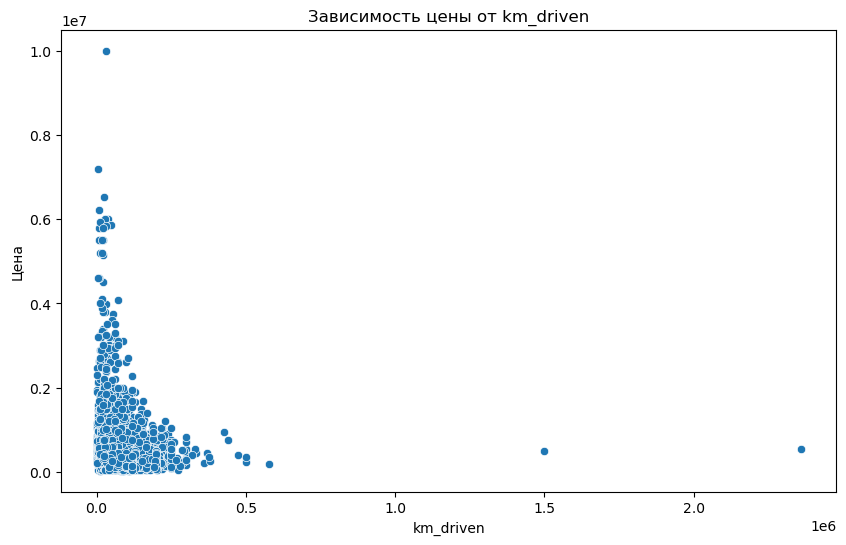

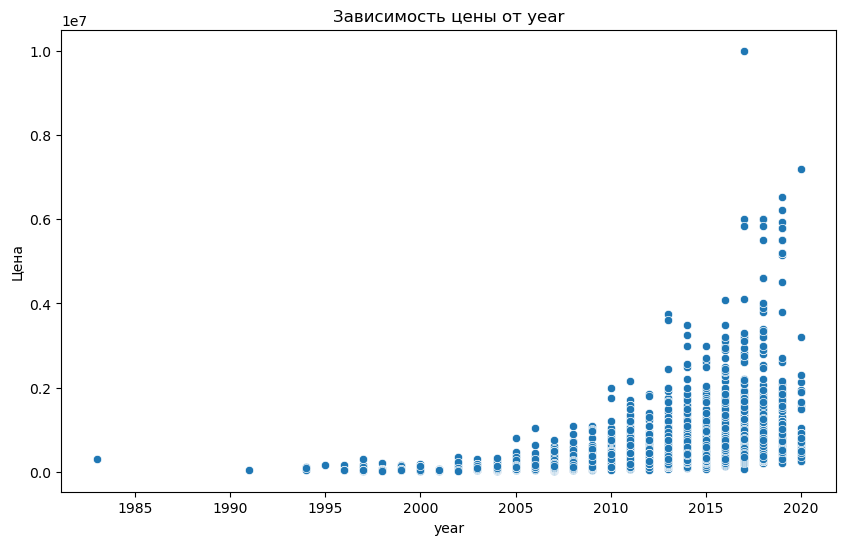

In [88]:
# 1) Сгенерировать новые признаки на основе уже существующих
plt.figure(figsize = (10, 6))
sns.scatterplot(data = df_train, x = 'km_driven', y = 'selling_price')
plt.xlabel('km_driven')
plt.ylabel('Цена')
plt.title('Зависимость цены от km_driven')
plt.show()

plt.figure(figsize = (10, 6))
sns.scatterplot(data = df_train, x = 'year', y = 'selling_price')
plt.xlabel('year')
plt.ylabel('Цена')
plt.title('Зависимость цены от year')
plt.show()

X_train_cat['max_power_per_engine'] = X_train_cat['max_power'] / X_train_cat['engine']
X_test_cat['max_power_per_engine'] = X_test_cat['max_power'] / X_test_cat['engine']

X_train_cat['max_power_per_torque'] = X_train_cat['max_power'] / X_train_cat['torque']
X_test_cat['max_power_per_torque'] = X_test_cat['max_power'] / X_test_cat['torque']

X_train_cat['year_squared'] = X_train_cat['year'] ** 2
X_test_cat['year_squared'] = X_test_cat['year'] ** 2

X_train_cat['km_driven_log'] = np.log(X_train_cat['km_driven'])
X_test_cat['km_driven_log'] = np.log(X_test_cat['km_driven'])

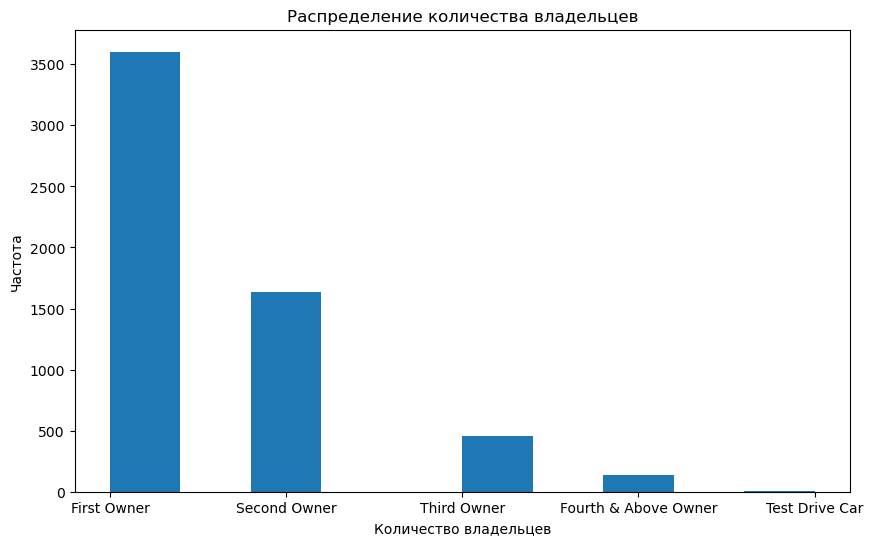

In [89]:
# 2) Добыть новые признаки
plt.figure(figsize = (10, 6))
plt.hist(df_train['owner'])
plt.xlabel('Количество владельцев')
plt.ylabel('Частота')
plt.title('Распределение количества владельцев')
plt.show()

X_train_cat['owner_3_or_morе'] = df_train['owner'].apply(lambda x: 0 if (x.split()[0] == 'First' or x.split()[0] == 'Second') else 1)
X_test_cat['owner_3_or_morе'] = df_test['owner'].apply(lambda x: 0 if (x.split()[0] == 'First' or x.split()[0] == 'Second') else 1)

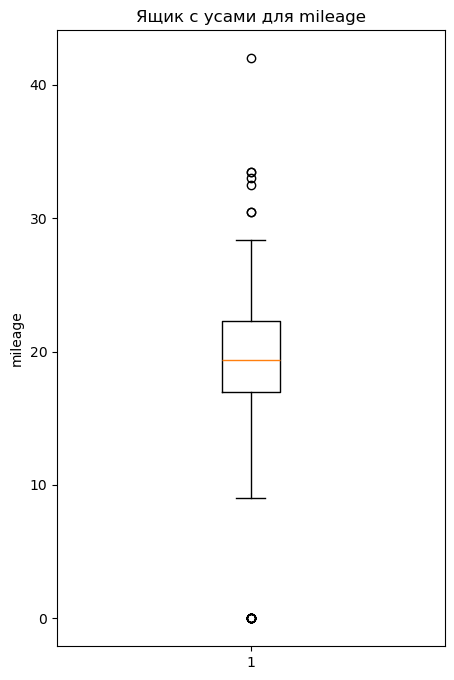

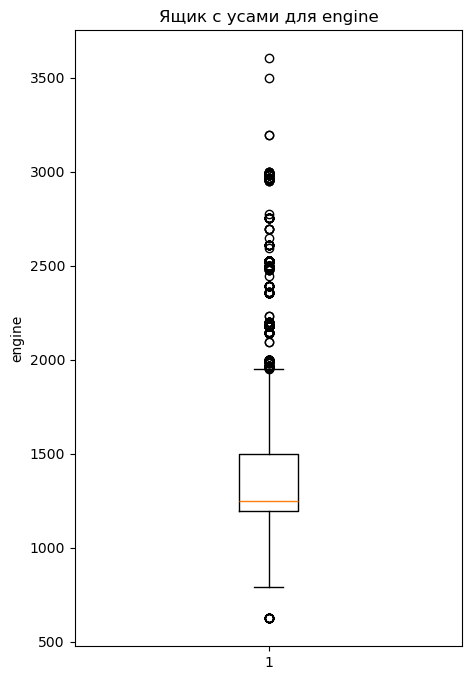

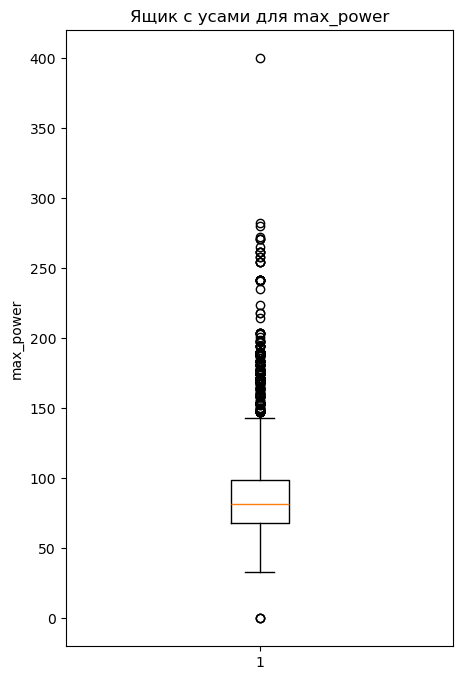

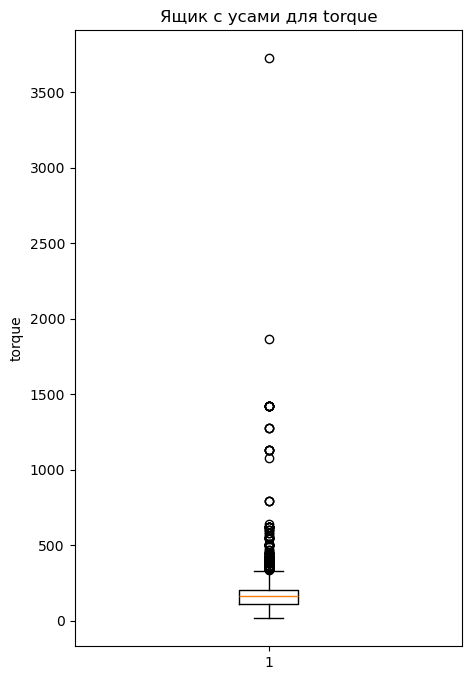

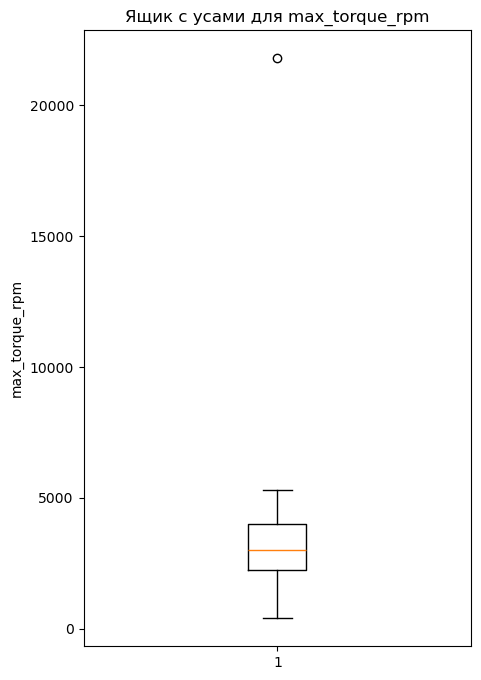

In [90]:
# 3) Поработать с уже имеющимися
cols = ['mileage', 'engine', 'max_power', 'torque', 'max_torque_rpm']

for col in cols:
    fig, ax = plt.subplots(figsize = (5, 8))
    ax.boxplot(X_train_cat[col])
    ax.set_ylabel(col)
    ax.set_title(f'Ящик с усами для {col}');
    
    Q1 = X_train_cat[col].quantile(0.25)
    Q3 = X_train_cat[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
            
    X_train_cat.loc[X_train_cat[col] < lower_bound, col] = lower_bound
    X_train_cat.loc[X_train_cat[col] > upper_bound, col] = upper_bound
            
    X_test_cat.loc[X_test_cat[col] < lower_bound, col] = lower_bound
    X_test_cat.loc[X_test_cat[col] > upper_bound, col] = upper_bound

In [91]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'max_iter': [1000, 5000]
}

ridge = Ridge()

grid_search = GridSearchCV(
    estimator = ridge,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 10
)

grid_search.fit(X_train_cat, y_train)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'max_iter': [1000, 5000]},
             scoring='r2')

In [92]:
best_params = grid_search.best_params_
best_params

{'alpha': 0.1, 'max_iter': 1000}

In [93]:
ridge = Ridge(alpha = 0.1, max_iter = 1000)
ridge.fit(X_train_cat, y_train)

Ridge(alpha=0.1, max_iter=1000)

In [94]:
y_pred_train = ridge.predict(X_train_cat)
y_pred_test = ridge.predict(X_test_cat)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

R2 на train: 0.767059199332947
R2 на test: 0.7745900582294853
MSE на train: 66769764038.95976
MSE на test: 129572071254.49078


In [ ]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

en = ElasticNet()

grid_search = GridSearchCV(
    estimator = en,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 10
)

grid_search.fit(X_train_cat, y_train)

In [ ]:
best_params = grid_search.best_params_
best_params

In [ ]:
en = ElasticNet(alpha = 0.01, l1_ratio = 0.9)
en.fit(X_train_cat, y_train)

In [ ]:
y_pred_train = en.predict(X_train_cat)
y_pred_test = en.predict(X_test_cat)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

In [ ]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'max_iter': [1000, 5000]
}

lasso = Lasso()

grid_search = GridSearchCV(
    estimator = lasso,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 10
)

grid_search.fit(X_train_cat, y_train)

In [ ]:
best_params = grid_search.best_params_
best_params

In [ ]:
lasso = Lasso(alpha = 10, max_iter = 5000)
lasso.fit(X_train_cat, y_train)

In [ ]:
y_pred_train = lasso.predict(X_train_cat)
y_pred_test = lasso.predict(X_test_cat)

print(f'R2 на train: {r2_score(y_train, y_pred_train)}')
print(f'R2 на test: {r2_score(y_test, y_pred_test)}')

print(f'MSE на train: {mean_squared_error(y_train, y_pred_train)}')
print(f'MSE на test: {mean_squared_error(y_test, y_pred_test)}')

**В первой части были сгенерированы различные отношения признаков и их модификации (логарифм и квадрат на основе графиков зависимостей). Во второй части был добавлен признак, отвечающий за количество владельцев (3 и более). В третьей части в выбранных числовых признаках было решено попробовать заменить выбросы на значения границ. Лучшим образом себя показали Ridge и Lasso, но на результат в целом данные манипуляции не повлияли.**

# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 23 (0.25 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какаю лучше всего решает задачу бизнеса

In [ ]:
def business_metrics(y_true, y_pred):
    percent_diff = np.abs((y_pred - y_true) / y_true)
    percent_10 = np.mean(percent_diff <= 0.1)
    
    return percent_10

models = [lasso, en, ridge]

for model in models:
    y_pred_train = model.predict(X_train_cat)
    y_pred_test = model.predict(X_test_cat)
    
    print(f'Бизнес метрика на train для {model}: {business_metrics(y_train, y_pred_train)}')
    print(f'Бизнес метрика на test для {model}: {business_metrics(y_test, y_pred_test)}\n')

**Лучше всего на данной бизнес метрике показала себя Ridge**

### **Задание 24 (0.25 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какаю лучше всего решает задачу бизнеса



In [ ]:
def your_business_metrics(y_true, y_pred):
    errors = (y_pred - y_true) / y_true
    safe_predictions = ((errors >= -0.05) & (errors <= 0.15))
    
    return np.mean(safe_predictions)
    

models = [lasso, en, ridge]

for model in models:
    y_pred_train = model.predict(X_train_cat)
    y_pred_test = model.predict(X_test_cat)
    
    print(f'Бизнес метрика на train для {model}: {your_business_metrics(y_train, y_pred_train)}')
    print(f'Бизнес метрика на test для {model}: {your_business_metrics(y_test, y_pred_test)}\n')

**Лучшими моделями на данной бизнес метрике оказались Lasso и Ridge**

# **Часть 6 (1 балл) | Оформление результатов**

### **Задание 25**

**Результаты вашей работы** необходимо разместить в своем Гитхабе. Далее в этот же репозиторий вы прикрепите вторую часть. Под результатами первой части понимаем следующее:
* ``.ipynb``-ноутбук со всеми проведёнными вами экспериментами (output'ы ячеек, разумеется, сохранить)
* ``.pickle``-файл с сохранёнными весами модели, коэффициентами скейлинга и прочими числовыми значениями, которые могут понадобиться для инференса
* ``.md``-файл с выводами про проделанной вами работе:
    * что было сделано
    * с какими результатами
    * что дало наибольший буст в качестве
    * что сделать не вышло и почему (это нормально, даже хорошо😀)

**За что могут быть сняты баллы в этом пункте:**
* за отсутствие ``.pickle``-файла с весами использованной модели
* за недостаточную аналитику в ``.md``-файле
* за оформление и логику кода (в определённом смысле это тоже элемент оформления решения)

In [97]:
import pickle

model_artifacts = {
    'model': ridge,
    'encoder': ohe,
    'target': 'selling_price',
    'feature_names': X_train_cat.columns.tolist(),
    'metrics': {
        'train_mse': mean_squared_error(y_train, y_pred_train),
        'test_mse': mean_squared_error(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test)
    }
}

with open('car_price_model.pickle', 'wb') as f:
    pickle.dump(model_artifacts, f)